# Tesla EV Sales Analysis & Delivery Prediction


Dataset: 2640 rows, 4 regions, 5 models, monthly data from 2015 to 2025.

In [26]:
# basic libraries for handling data
import pandas as pd
import numpy as np

# for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

# for splitting data and checking model accuracy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# xgboost - a more advanced model, not built into sklearn so installed separately
from xgboost import XGBRegressor

# for the time series forecasting part at the end
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_style('whitegrid')

##Step 1: Load the dataset

In [27]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(df.shape)  # (rows, columns)
df.head()  # first 5 rows

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


##Step 2: Check the data before touching anything
check for missing values, duplicate rows and wrong data types first.

In [28]:
df.info()  # shows column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [29]:
print('missing values per column:')
print(df.isnull().sum())

print('\nduplicate rows:', df.duplicated().sum())
# if both of the above are 0, the data is already clean

missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

duplicate rows: 0


## Step 3: Basic preprocessing
Year and Month are separate columns right now. Combining them into one proper Date column makes it much easier to plot trends

In [30]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

df = df.sort_values('Date').reset_index(drop=True)  # put everything in time order

df[['Year', 'Month', 'Date']].head()

,Year,Month,Date
0,2015,1,2015-01-01
1,2015,1,2015-01-01
2,2015,1,2015-01-01
3,2015,1,2015-01-01
4,2015,1,2015-01-01


## Step 4: Exploratory Data Analysis (EDA)


In [31]:
print(df['Region'].value_counts())
print()
print(df['Model'].value_counts())
# this just tells us if the data is balanced across categories

Region
Asia             660
Middle East      660
North America    660
Europe           660
Name: count, dtype: int64

Model
Model Y       528
Model 3       528
Cybertruck    528
Model S       528
Model X       528
Name: count, dtype: int64


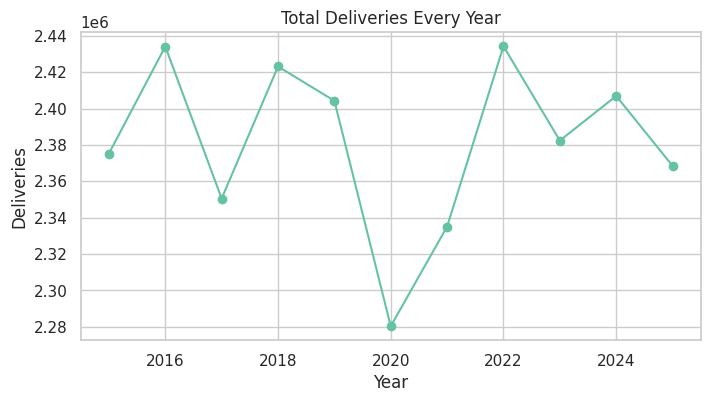

In [32]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8, 4))
plt.plot(yearly_deliveries.index, yearly_deliveries.values, marker='o')
plt.title('Total Deliveries Every Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.show()

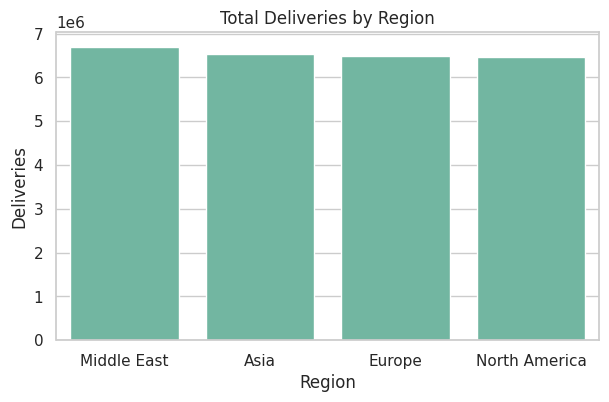

In [33]:
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=region_deliveries.index, y=region_deliveries.values)
plt.title('Total Deliveries by Region')
plt.ylabel('Deliveries')
plt.show()

### EDA - correlation
Correlation just tells us if two numbers tend to go up/down together. Closer to 1 or -1 means a strong relationship, closer to 0 means basically no relationship.

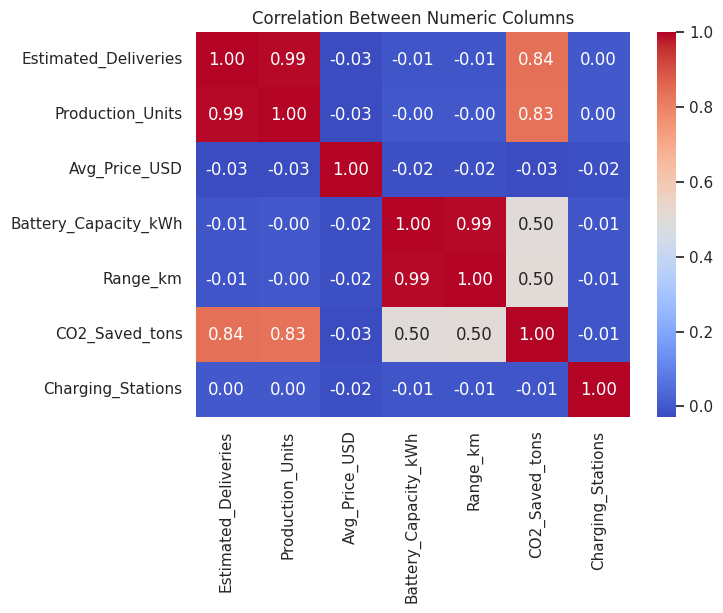

In [34]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Numeric Columns')
plt.show()

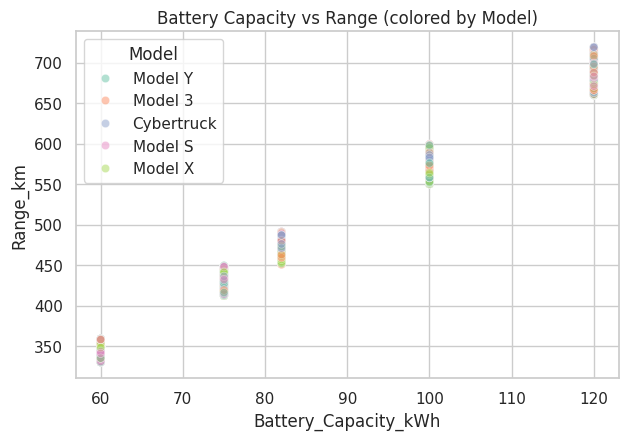

In [35]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='Battery_Capacity_kWh', y='Range_km', hue='Model', alpha=0.5)
plt.title('Battery Capacity vs Range (colored by Model)')
plt.show()

## Step 5: Feature Engineering


In [36]:
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']

df_model = pd.get_dummies(df, columns=['Region', 'Model'], drop_first=True)
# drop_first=True avoids creating one extra unnecessary column

df_model.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Price_per_kWh,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,2015,1,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,919.718833,False,False,False,False,False,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,892.894000,False,True,False,True,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1714.809667,False,True,False,False,False,False,False
3,2015,1,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1280.028293,False,False,True,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1073.033293,False,False,False,True,False,False,False


## Step 6: Train-Test Split
We don't train and test on the same data - 80% of rows go into training, and the model is tested on the remaining 20% it has never seen.

In [37]:
feature_cols = ['Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                 'Price_per_kWh', 'Charging_Stations'] + \
                [c for c in df_model.columns if c.startswith('Region_') or c.startswith('Model_')]

X = df_model[feature_cols]
y = df_model['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train size:', X_train.shape, ' test size:', X_test.shape)

train size: (2112, 13)  test size: (528, 13)


In [38]:

def train_and_check(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    print(f'{name:18s}  R2={r2:6.3f}   MAE={mae:8,.0f}   RMSE={rmse:8,.0f}')
    return model, r2, mae, rmse

# R2 -> how much of the variation in deliveries the model explains (1.0 = perfect, 0 = no better than guessing the average)
# MAE -> average error in units
# RMSE -> similar to MAE but punishes big mistakes more

## Step 7: Model 1 - Linear Regression
The simplest model. Just fits a straight line through the data.

In [39]:
results = {}
results['Linear Regression'] = train_and_check(LinearRegression(), 'Linear Regression')

Linear Regression   R2=-0.008   MAE=   3,074   RMSE=   3,886


## Step 8: Model 2 - Decision Tree
Instead of one straight line, a tree splits the data into smaller groups using yes/no questions until it can make a prediction.

In [40]:
results['Decision Tree'] = train_and_check(DecisionTreeRegressor(max_depth=8, random_state=42), 'Decision Tree')

Decision Tree       R2=-0.230   MAE=   3,338   RMSE=   4,292


## Step 9: Model 3 - Random Forest
 Random Forest builds many different trees and averages their answers - usually more stable and accurate.

In [41]:
results['Random Forest'] = train_and_check(RandomForestRegressor(n_estimators=200, random_state=42), 'Random Forest')

Random Forest       R2=-0.040   MAE=   3,139   RMSE=   3,947


## Step 10: Model 4 - XGBoost
XGBoost also builds many trees, but each new tree is trained to fix the mistakes of the previous ones (this is called boosting).

In [43]:
results['XGBoost'] = train_and_check(XGBRegressor(n_estimators=200, learning_rate=0.08, random_state=42), 'XGBoost')

XGBoost             R2=-0.155   MAE=   3,339   RMSE=   4,160


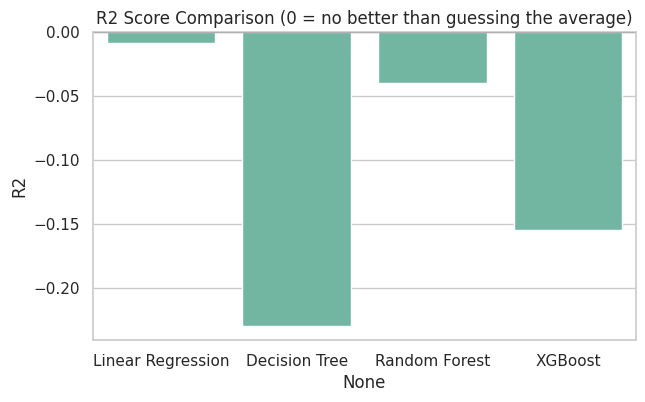

,R2,MAE,RMSE
Linear Regression,-0.008062,3074.050642,3886.327659
Decision Tree,-0.229707,3337.702111,4292.364931
Random Forest,-0.039621,3139.253201,3946.692151
XGBoost,-0.155143,3339.011719,4160.194467


In [44]:
scores = pd.DataFrame({name: [r2, mae, rmse] for name, (_, r2, mae, rmse) in results.items()},
                      index=['R2', 'MAE', 'RMSE']).T

plt.figure(figsize=(7, 4))
sns.barplot(x=scores.index, y=scores['R2'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('R2 Score Comparison (0 = no better than guessing the average)')
plt.show()

scores

## Step 11: Hyperparameter Tuning
Every model has settings we can adjust called hyperparameters - like how many trees, how deep each tree goes, etc. Instead of guessing, GridSearchCV tries out every combination from a list we give it and tells us which one worked best.

In [46]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 6, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print('best settings found:', grid.best_params_)

best settings found: {'max_depth': 6, 'min_samples_leaf': 4, 'n_estimators': 200}


In [47]:
tuned_preds = grid.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_preds)
tuned_mae = mean_absolute_error(y_test, tuned_preds)

print('Random Forest before tuning -> R2:', round(results['Random Forest'][1], 3))
print('Random Forest after tuning  -> R2:', round(tuned_r2, 3))
# if these two numbers are close, tuning didn't help much - the model just isn't finding strong patterns

Random Forest before tuning -> R2: -0.04
Random Forest after tuning  -> R2: 0.01


## Step 12: Time Series Forecasting
just adding up total deliveries every month gives us one continuous timeline we can try to forecast forward.

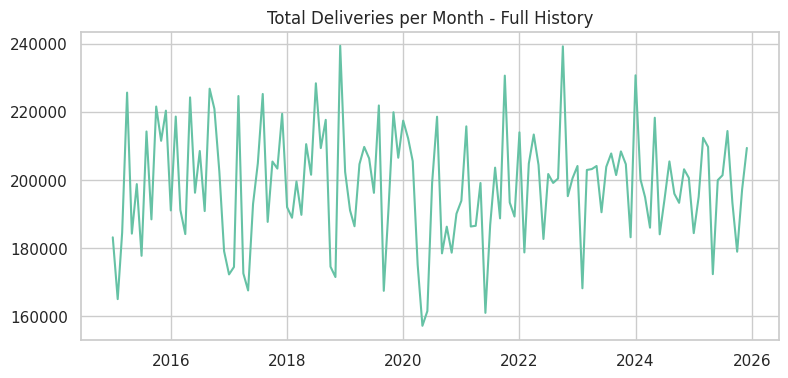

In [48]:
monthly_total = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(9, 4))
plt.plot(monthly_total.index, monthly_total.values)
plt.title('Total Deliveries per Month - Full History')
plt.show()

**Simplest forecasting idea: moving average.** Just take the average of the last few months and use that as a smoothed-out trend line.

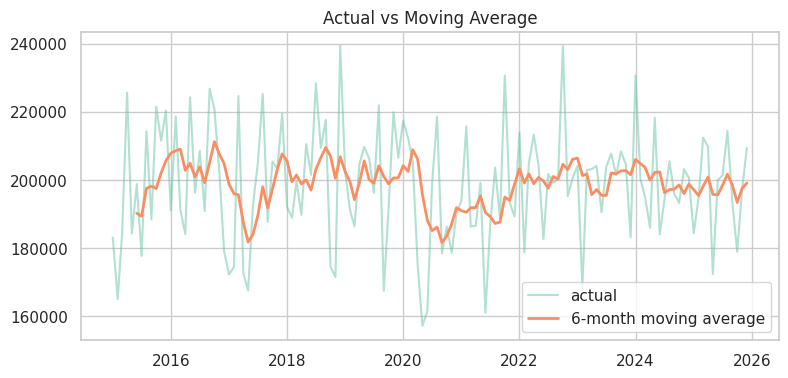

In [49]:
rolling_avg = monthly_total.rolling(window=6).mean()  # average of the last 6 months, rolled forward

plt.figure(figsize=(9, 4))
plt.plot(monthly_total.index, monthly_total.values, label='actual', alpha=0.5)
plt.plot(rolling_avg.index, rolling_avg.values, label='6-month moving average', linewidth=2)
plt.legend()
plt.title('Actual vs Moving Average')
plt.show()

** Holt-Winters Exponential Smoothing.** This automatically figures out the trend (going up/down) and seasonality (repeating yearly pattern, like higher deliveries in certain months) on its own and uses both to forecast forward.

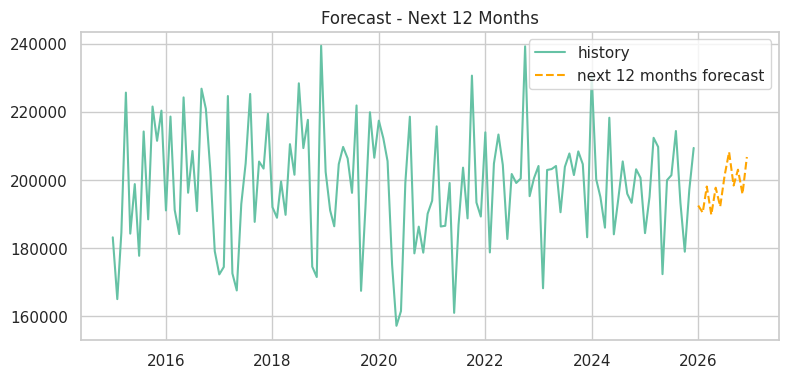

forecasted total for next 12 months: 2374174
actual total of last 12 months: 2368462


In [50]:
monthly_total.index.freq = 'MS'  # tell statsmodels this is monthly data

hw_model = ExponentialSmoothing(monthly_total, trend='add', seasonal='add', seasonal_periods=12).fit()
future_forecast = hw_model.forecast(12)  # predict the next 12 months

plt.figure(figsize=(9, 4))
plt.plot(monthly_total.index, monthly_total.values, label='history')
plt.plot(future_forecast.index, future_forecast.values, '--', label='next 12 months forecast', color='orange')
plt.legend()
plt.title('Forecast - Next 12 Months')
plt.show()

print('forecasted total for next 12 months:', round(future_forecast.sum()))
print('actual total of last 12 months:', round(monthly_total[-12:].sum()))

## Conclusion

- Data was already clean - no missing values, no duplicates.
- Region and Model are both perfectly balanced (660 rows per region, 528 per model).
- All four models (Linear Regression, Decision Tree, Random Forest, XGBoost) gave R2 scores at or below 0. That basically means none of them did better than just guessing the average delivery number every time. Linear Regression was technically "least bad" at -0.008.
- Tuning Random Forest with GridSearchCV improved it from R2 = -0.04 to R2 = 0.01 - a small improvement, but still close to zero. This tells me the columns we have don't actually have a strong relationship with deliveries in this dataset, no matter which model or settings we use.
- The interesting part: even though predicting deliveries row-by-row didn't work well, forecasting the total monthly deliveries with Holt-Winters worked decently - the forecasted next 12 months (2.37M) came out very close to the actual last 12 months (2.37M). So the data has a learnable pattern at the big-picture monthly level, just not at the detailed region+model level.
